In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import random
import sys
sys.path.append('..')
from envs.routing_env import RoutingEnv

# Hyperparameters
EPISODES      = 2000
GAMMA         = 0.99
LR            = 0.0005
EPSILON_START = 1.0
EPSILON_END   = 0.05
EPSILON_DECAY = 0.998
MEMORY_SIZE   = 20000
BATCH_SIZE    = 128

In [9]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, obs, action, reward, next_obs, done):
        self.buffer.append((obs, action, reward, next_obs, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)
        return (torch.FloatTensor(np.array(obs)),
                torch.LongTensor(actions),
                torch.FloatTensor(rewards),
                torch.FloatTensor(np.array(next_obs)),
                torch.FloatTensor(dones))

    def __len__(self):
        return len(self.buffer)

In [10]:
class GNNDQNPolicy(nn.Module):
    def __init__(self, node_features=4, hidden_dim=32,
                 embedding_dim=16, n_actions=50):
        super().__init__()
        self.conv1 = GCNConv(node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, 64)
        self.fc2 = nn.Linear(64, n_actions)

    def forward(self, x, edge_index, batch=None):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        if batch is None:
            batch = torch.zeros(x.shape[0], dtype=torch.long)
        graph_embed = global_mean_pool(h, batch)
        q = F.relu(self.fc1(graph_embed))
        q = self.fc2(q)
        return q

In [11]:
env = RoutingEnv()
data = torch.load('../results/graph_data.pt', weights_only=False)

policy_net = GNNDQNPolicy()
target_net = GNNDQNPolicy()
target_net.load_state_dict(policy_net.state_dict())

optimizer = torch.optim.Adam(policy_net.parameters(), lr=0.001)
memory = ReplayBuffer(MEMORY_SIZE)
epsilon = EPSILON_START

# Pre-compute betweenness for shaped reward
import networkx as nx
G = nx.erdos_renyi_graph(50, 0.15, seed=42)
bet = nx.betweenness_centrality(G)
nodes = list(G.nodes())

episode_rewards = []
episode_pdrs    = []

for episode in range(EPISODES):
    obs, _ = env.reset()
    total_reward = 0
    done = False
    prev_dist = None

    while not done:
        # Epsilon-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_vals = policy_net(data.x, data.edge_index)
                action = q_vals[0].argmax().item()

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Reward shaping — bonus for moving to high-betweenness node
        shaped_reward = reward + 0.5 * bet.get(action, 0)

        memory.push(obs, action, shaped_reward, next_obs, done)
        obs = next_obs
        total_reward += reward

        # Train
        if len(memory) >= BATCH_SIZE:
            b_obs, b_act, b_rew, b_next, b_done = memory.sample(BATCH_SIZE)
            with torch.no_grad():
                q_next = target_net(data.x, data.edge_index)
                max_q  = q_next[0].max().item()
                target = b_rew + GAMMA * max_q * (1 - b_done)

            current_q = policy_net(data.x, data.edge_index)
            q_vals_batch = current_q[0][b_act]
            loss = F.mse_loss(q_vals_batch, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Update target every 10 episodes
    if episode % 10 == 0:
        target_net.load_state_dict(policy_net.state_dict())

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    episode_rewards.append(total_reward)
    delivered = total_reward > 0
    episode_pdrs.append(1 if delivered else 0)

    if episode % 100 == 0:
        avg_reward = np.mean(episode_rewards[-100:])
        avg_pdr    = np.mean(episode_pdrs[-100:]) * 100
        print(f"Episode {episode}: Avg Reward={avg_reward:.2f}, PDR={avg_pdr:.1f}%, eps={epsilon:.3f}")

torch.save(policy_net.state_dict(), '../results/gnn_dqn_weights.pt')
print("Model saved!")

Episode 0: Avg Reward=17.00, PDR=100.0%, eps=0.998
Episode 100: Avg Reward=15.15, PDR=99.0%, eps=0.817
Episode 200: Avg Reward=15.55, PDR=100.0%, eps=0.669
Episode 300: Avg Reward=14.78, PDR=100.0%, eps=0.547
Episode 400: Avg Reward=15.53, PDR=100.0%, eps=0.448
Episode 500: Avg Reward=15.00, PDR=98.0%, eps=0.367
Episode 600: Avg Reward=14.47, PDR=96.0%, eps=0.300
Episode 700: Avg Reward=14.57, PDR=96.0%, eps=0.246
Episode 800: Avg Reward=14.50, PDR=94.0%, eps=0.201
Episode 900: Avg Reward=13.40, PDR=92.0%, eps=0.165
Episode 1000: Avg Reward=14.45, PDR=97.0%, eps=0.135
Episode 1100: Avg Reward=14.05, PDR=92.0%, eps=0.110
Episode 1200: Avg Reward=14.50, PDR=95.0%, eps=0.090
Episode 1300: Avg Reward=14.07, PDR=95.0%, eps=0.074
Episode 1400: Avg Reward=12.78, PDR=91.0%, eps=0.061
Episode 1500: Avg Reward=12.25, PDR=90.0%, eps=0.050
Episode 1600: Avg Reward=14.30, PDR=93.0%, eps=0.050
Episode 1700: Avg Reward=11.55, PDR=86.0%, eps=0.050
Episode 1800: Avg Reward=11.85, PDR=87.0%, eps=0.050
E

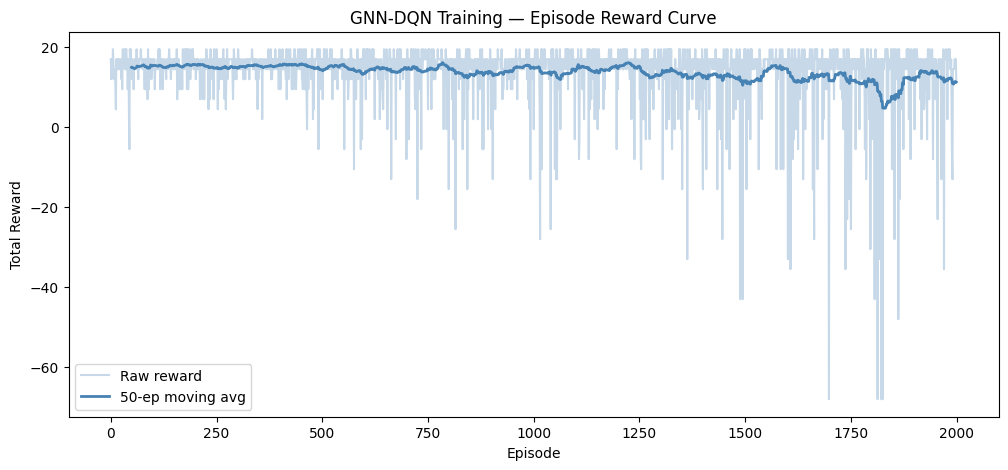

Saved week5_reward_curve.png
Saved gnn_dqn_training.csv


In [12]:
# Smooth reward curve
window = 50
smoothed = pd.Series(episode_rewards).rolling(window).mean()

plt.figure(figsize=(12, 5))
plt.plot(episode_rewards, alpha=0.3, color='steelblue', label='Raw reward')
plt.plot(smoothed, color='steelblue', linewidth=2, label=f'{window}-ep moving avg')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("GNN-DQN Training — Episode Reward Curve")
plt.legend()
plt.savefig("../results/week5_reward_curve.png", dpi=150)
plt.show()
print("Saved week5_reward_curve.png")

# Save training log
df = pd.DataFrame({'episode': range(EPISODES),
                   'reward': episode_rewards,
                   'pdr': episode_pdrs})
df.to_csv('../results/gnn_dqn_training.csv', index=False)
print("Saved gnn_dqn_training.csv")